In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import glob
import pandas as pd
import math
from math import sqrt
import random
import scipy
from scipy.stats import mannwhitneyu
import seaborn as sns

plt.style.use('styleNB.mplstyle')

wt = 'dHL60KW'
ko = 'dHL60TMEM154KO'
res = 'dHL60TMEM154KO-clone1galvanin-GFP-HA'

E_levels = [0, 1, 3]

# markers for different E_field strengths 
# when plotting for a single cell type
marker_dict = {
    0: 'o',
    1: 's',
    3: 'D'
}

def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out

##########################
# colors for each cell type

# celllines = df.celltype.unique() 
# colors = sns.color_palette("tab10")
# color_dict = dict(zip(df.celltype.unique(), colors))    
# color_dict.update({'dHL60KW':'#B8BABC'})

color_dict = {'dHL60KW': '#B8BABC',
             'dHL60TMEM154KO': (1.0, 0.4980392156862745, 0.054901960784313725),
             'dHL60TMEM154KO-clone1galvanin-GFP-HA': (0.17254901960784313,
              0.6274509803921569,
              0.17254901960784313)}


# Figure 2 Related

### Load in data and perform general filter (remove short trajectories, non-motile cells, and cells likely on the top or bottom of side (ie not migrating in 3D)

In [34]:
# Load data

f_compiled = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_tracking.csv'

df = pd.read_csv(f_compiled)
df = df[['cell', 'frame', 'x', 'y', 'z', 'celltype', 'E_V_cm',
       'date', 'trial', 'user']]
df = df[df.celltype != 'dHL60TMEM154KO-clone1galvanin-GFP-HA']

f_rescue_filtered = '../../data/processed_3D_tracking/20240424_compiled_galvaninKOlines_rescue_tracking_GFPplus.csv'
df_gfp = pd.read_csv(f_rescue_filtered)
df_gfp = df_gfp[['cell', 'frame', 'x', 'y', 'z',
       'celltype', 'E_V_cm', 'date', 'trial', 'user']]


df = pd.concat([df, df_gfp], ignore_index = True)

df = df.replace('dHL60TMEM154KO-clone1', 'dHL60TMEM154KO')
df = df.replace('dHL60TMEM154KO-clone12', 'dHL60TMEM154KO')

#############################
# Step 1: Remove cells at the periphery
#############################
df_temp_ = pd.DataFrame()
for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df = df_temp_

#############################
# Step 2: Filter trajectories
#############################
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 20:
        continue

    if d_.E_V_cm.unique() not in E_levels:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0], row.z.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Filter: skip low-displacement tracks
    total_movement = np.sum(np.linalg.norm(np.diff(positions[:, :2], axis=0), axis=1))
    if total_movement < 15:
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'cell': g[5],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1],
            'z': positions[:, 2]
        })
    ], ignore_index=True)


# Step 3: subsample every three minutes
df_intervals_3 = parse_trajectories(df_filtered_tracks, frame_step=3)

# Plots of Single Cell Trajectories

## Plots of absolute tracks

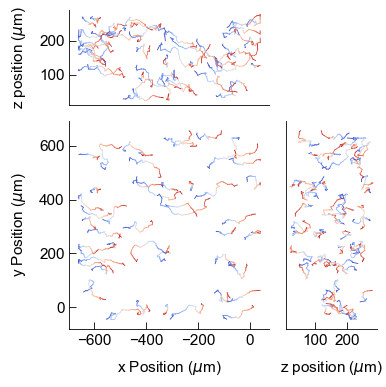

In [35]:
# 20240211_dHL60KW_3Vcm_1_user_NB_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60KW']
df_temp = df_temp[df_temp.date == 20240211]
df_temp = df_temp[df_temp.user == 'NB']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

# ignore cells near the top and bottom of the slide (since they might be migrating on surface instead of 3D)
df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 280):
        continue
    elif np.any(d_.z < 20):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

####################################
####################################

fig = plt.figure(figsize=(4,4))

gs = gridspec.GridSpec(2, 2,height_ratios=[1,(1024.0*ip)/300], width_ratios=[(1024.0*ip)/300,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[3])

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red
        
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x - 1024.0*ip
    y = 1024.0*ip - d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax1.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
#     ax1.set_ylim(0,300)
#     ax1.set_xlim(-676,0)  
    ax1.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax2.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax2.set_xlabel(r'x Position ($\mu$m)')
    ax2.set_ylabel(r'y Position ($\mu$m)')
#     ax2.set_xlim(0,-676)
#     ax2.set_ylim(0,676)  
    
    for i in range(len(x) - 1):
        ax3.plot(z[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax3.set_xlabel(r'z position ($\mu$m)')
#     ax3.set_xlim(0,300)
#     ax3.set_ylim(0,676)
        

    ax1.xaxis.set_visible(False)
    ax3.yaxis.set_visible(False)

plt.tight_layout()

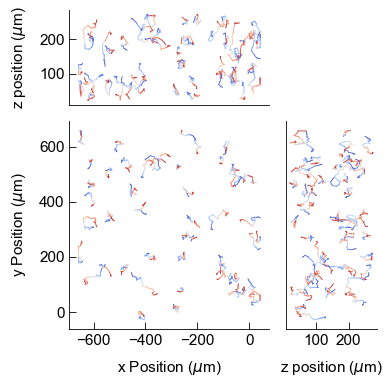

In [36]:
# 20240320_dHL60TMEM154KO-clone1_3Vcm_1_user_TE_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60TMEM154KO']
df_temp = df_temp[df_temp.date == 20240320]
df_temp = df_temp[df_temp.user == 'TE']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

# ignore cells near the top and bottom of the slide (since they might be migrating on surface instead of 3D)
df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 280):
        continue
    elif np.any(d_.z < 20):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

#########################
#########################

fig = plt.figure(figsize=(4,4))

gs = gridspec.GridSpec(2, 2,height_ratios=[1,(1024.0*ip)/300], width_ratios=[(1024.0*ip)/300,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[3])

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red


for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x - 1024.0*ip
    y = 1024.0*ip - d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax1.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
#     ax1.set_ylim(0,300)
#     ax1.set_xlim(-676,0)  
    ax1.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax2.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax2.set_xlabel(r'x Position ($\mu$m)')
    ax2.set_ylabel(r'y Position ($\mu$m)')
#     ax2.set_xlim(0,-676)
#     ax2.set_ylim(0,676)  
    
    for i in range(len(x) - 1):
        ax3.plot(z[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax3.set_xlabel(r'z position ($\mu$m)')
#     ax3.set_xlim(0,300)
#     ax3.set_ylim(0,676)
        

    ax1.xaxis.set_visible(False)
    ax3.yaxis.set_visible(False)

plt.tight_layout()

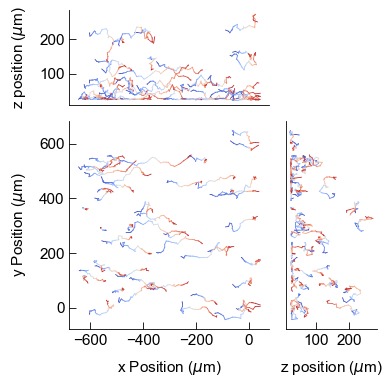

In [37]:
# 20240313_dHL60TMEM154KO-clone1galvanin-GFP-HA_3Vcm_1_user_HK_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

# ignore cells near the top and bottom of the slide (since they might be migrating on surface instead of 3D)
df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 280):
        continue
    elif np.any(d_.z < 20):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

#########################
#########################

fig = plt.figure(figsize=(4,4))

gs = gridspec.GridSpec(2, 2,height_ratios=[1,(1024.0*ip)/300], width_ratios=[(1024.0*ip)/300,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])
ax3 = plt.subplot(gs[3])

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x - 1024.0*ip
    y = 1024.0*ip - d_.y
    z = d_.z
    time = np.arange(len(x))

    
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax1.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
#     ax1.set_ylim(0,300)
#     ax1.set_xlim(-676,0)  
    ax1.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax2.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax2.set_xlabel(r'x Position ($\mu$m)')
    ax2.set_ylabel(r'y Position ($\mu$m)')
#     ax2.set_xlim(0,-676)
#     ax2.set_ylim(0,676)  
    
    for i in range(len(x) - 1):
        ax3.plot(z[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax3.set_xlabel(r'z position ($\mu$m)')
#     ax3.set_xlim(0,300)
#     ax3.set_ylim(0,676)
        

    ax1.xaxis.set_visible(False)
    ax3.yaxis.set_visible(False)

plt.tight_layout()

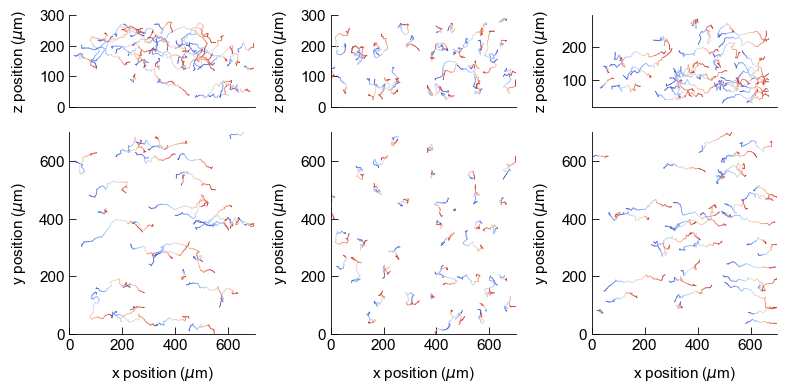

In [38]:
fig = plt.figure(figsize=(8,4))

gs = gridspec.GridSpec(2, 3,height_ratios=[1,(1024.0*ip)/300])

###########################
###########################
# Column 1
###########################
###########################
ax_wt_xz = plt.subplot(gs[0])
ax_wt_xy = plt.subplot(gs[3])


# 20240211_dHL60KW_3Vcm_1_user_NB_abs_trajectories.pdf
df_temp = df[df.celltype == 'dHL60KW']
df_temp = df_temp[df_temp.date == 20240211]
df_temp = df_temp[df_temp.user == 'NB']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 280):
        continue
    elif np.any(d_.z < 20):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    if count == 40:
        continue

    x = d_.x 
    y = d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax_wt_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xz.set_ylim(0,300)
    ax_wt_xz.set_xlim(0,700)  
    ax_wt_xz.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_wt_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xy.set_xlabel(r'x position ($\mu$m)')
    ax_wt_xy.set_ylabel(r'y position ($\mu$m)')
    ax_wt_xy.set_xlim(0,700)
    ax_wt_xy.set_ylim(0,700)  
    

    ax_wt_xz.xaxis.set_visible(False)
    count += 1
    

#############################
###########################
# Column 2
###########################
###########################

ax_ko_xz = plt.subplot(gs[1])
ax_ko_xy = plt.subplot(gs[4])


df_temp = df[df.celltype == 'dHL60TMEM154KO']
df_temp = df_temp[df_temp.date == 20240320]
# df_temp = df_temp[df_temp.date == 20240229]
df_temp = df_temp[df_temp.user == 'TE']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 10):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)


ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist() , 50)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    if count == 40:
        continue

    x = d_.x
    y = d_.y
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax_ko_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_ko_xz.set_ylim(0,300)
    ax_ko_xz.set_xlim(0,700) 
    ax_ko_xz.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_ko_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_ko_xy.set_xlabel(r'x position ($\mu$m)')
    ax_ko_xy.set_ylabel(r'y position ($\mu$m)')
    ax_ko_xy.set_xlim(0,700)
    ax_ko_xy.set_ylim(0,700)  
    
    ax_ko_xz.xaxis.set_visible(False)
    count += 1

    
###########################
###########################
# Column 3
###########################
###########################
ax_res_xz = plt.subplot(gs[2])
ax_res_xy = plt.subplot(gs[5])

df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 290):
        continue
    elif np.any(d_.z < 30):
        continue
    
    # Append the row to the DataFrame using concat
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()


ip = 0.642 # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

# random_50_numbers = random.sample(d.cell.unique().tolist() , 50)
random_50_numbers = random.sample(d.cell.unique().tolist() , 100)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

count = 0
for c, d_  in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    if count == 40:
        continue
    elif np.any([x< 10 for x in d_.z.values]):
        continue

    x = d_.x 
    y = d_.y 
    z = d_.z
    time = np.arange(len(x))
    
    # Normalize the time array to range from 0 to 1
    norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))
    
    for i in range(len(x) - 1):
        ax_res_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax1.set_ylim(0,300)
    ax1.set_xlim(0,700)  
    ax_res_xz.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_res_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_res_xy.set_xlabel(r'x position ($\mu$m)')
    ax_res_xy.set_ylabel(r'y position ($\mu$m)')
    ax_res_xy.set_xlim(0,700)
    ax_res_xy.set_ylim(0,700)  
    

    ax_res_xz.xaxis.set_visible(False)

    count += 1
    
plt.tight_layout()

# plt.savefig('../../figures/Figure2_draft1_tracks_3.pdf')


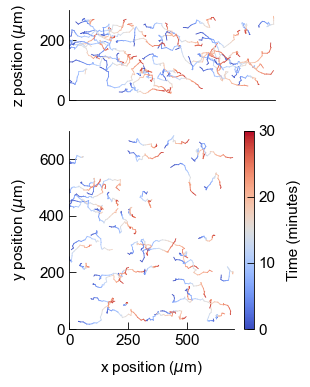

In [39]:
# Generate a plot with the colorbar, so that I can use it for the figure

fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, (1024.0 * 0.642) / 300])

ax_wt_xz = plt.subplot(gs[0])
ax_wt_xy = plt.subplot(gs[3])

# Filter the DataFrame
df_temp = df[df.celltype == 'dHL60KW']
df_temp = df_temp[df_temp.date == 20240211]
df_temp = df_temp[df_temp.user == 'NB']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp_ = pd.DataFrame()
for g, d_ in df_temp.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    if np.any(d_.z > 280):
        continue
    elif np.any(d_.z < 20):
        continue
    df_temp_ = pd.concat([df_temp_, d_], ignore_index=True)
    
df_temp_.head()

ip = 0.642  # ip = 200.0/303.0
d = df_temp_
num_cells = len(d.cell.unique())

random_50_numbers = random.sample(d.cell.unique().tolist(), 50)

# Create a colormap
cmap = plt.get_cmap('coolwarm')  # A colormap that goes from blue to red

for c, d_ in d.groupby('cell'):
    if c not in random_50_numbers:
        continue
    
    if len(d_) <= 15:
        continue

    x = d_.x 
    y = d_.y
    z = d_.z
    time = np.arange(d_.frame.min(), d_.frame.max())
    
    # Normalize the time array to range from 0 to 1 based on a fixed range of 0 to 30 minutes
    norm_time = (time - np.min(time)) / (30.0)  # 30 minutes max

    for i in range(len(x) - 1):
        ax_wt_xz.plot(x[i:i+2], z[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xz.set_ylim(0, 300)
    ax_wt_xz.set_xlim(0, 700)  
    ax_wt_xz.set_ylabel(r'z position ($\mu$m)')
    
    # Plot the trajectory on the first subplot
    for i in range(len(x) - 1):
        ax_wt_xy.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)
    ax_wt_xy.set_xlabel(r'x position ($\mu$m)')
    ax_wt_xy.set_ylabel(r'y position ($\mu$m)')
    ax_wt_xy.set_xlim(0, 700)
    ax_wt_xy.set_ylim(0, 700)  

    ax_wt_xz.xaxis.set_visible(False)

# Add a colorbar to the first subplot
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=30))  # 0 to 30 minutes
sm.set_array([])

# Set the ticks and labels for the colorbar
tick_positions = np.linspace(0, 30, num=4)  # Ticks at every 10 minutes (0, 10, 20, 30)
tick_labels = np.arange(0, 31, 10)  # Labels from 0 to 30 minutes at 10-minute intervals

cbar = fig.colorbar(sm, ax=ax_wt_xy, orientation='vertical', label='Time (minutes)')
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)

plt.tight_layout()

# plt.savefig('../../figures/Figure3_draft1_colormap.pdf')

## Plot of relative trajectories

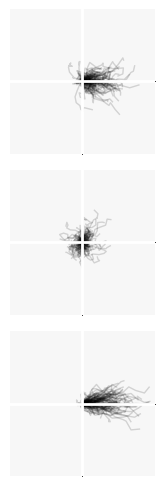

In [40]:
### Generate a plot of relative trajectories (for these tracks above; i.e. so that they all start at x,y,z = 0,0,0)

df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp = df[df.celltype == 'dHL60TMEM154KO']
df_temp = df_temp[df_temp.date == 20240320]
df_temp = df_temp[df_temp.user == 'TE']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]

df_temp = df[df.celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA']
df_temp = df_temp[df_temp.date == 20240313]
df_temp = df_temp[df_temp.user == 'HK']
df_temp = df_temp[df_temp.E_V_cm == 3]
df_temp = df_temp[df_temp.trial == 1]


fig, axs = plt.subplots(3,1, figsize=(4, 5))

df_traj = df_intervals_3[df_intervals_3.E_V_cm == 3].copy()
celltypes = [wt, ko, res]
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

for i, celltype in enumerate(celltypes):
    ax =axs[i]
    d = df_traj[df_traj.celltype == celltype]
    
    if celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
        d = d[d.date == 20240313]
        d = d[d.user == 'HK']
        d = d[d.trial == 1]
    elif celltype == 'dHL60TMEM154KO':
        d = d[d.date == 20240320]
        d = d[d.user == 'TE']
        d = d[d.trial == 1]
    elif celltype == 'dHL60TMEM154KO-clone1galvanin-GFP-HA':
        d = d[d.date == 20240313]
        d = d[d.user == 'HK']
        d = d[d.trial == 1]

    count_cell = 0

    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user']):
        if len(d_) < 5 or count_cell >= 125:
            continue

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax.plot(x_rel, y_rel, color='black', alpha=0.15, lw=1, zorder=10)
        count_cell += 1

    ax.axhline(0, color='white', lw=2, zorder=100)
    ax.axvline(0, color='white', lw=2, zorder=100)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.set_aspect('equal')
    ax.set_axisbelow(True)
    ax.set_facecolor('#f7f7f7')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    # ax.set_title(celltype, fontsize=10)

# Add E-field label on leftmost plot
# fig.axes[0].set_ylabel("300 mV/mm", fontsize=10, labelpad=10)
fig.axes[0].yaxis.set_label_coords(-0.2, 0.5)


plt.tight_layout()

# fig.savefig('../../figures/Figure2_rel_tracks_.pdf')

# Average speed calculations


Magnitude comparisons (KO vs WT): {0: {'U_stat': 8.0, 'p_value': 0.3151515151515151, 'n_a': 7, 'n_b': 4}, 1: {'U_stat': 29.0, 'p_value': 0.5727605727605728, 'n_a': 8, 'n_b': 6}, 3: {'U_stat': 7.0, 'p_value': 0.2303030303030303, 'n_a': 7, 'n_b': 4}}

Magnitude comparisons (Rescue vs WT): {0: {'U_stat': 10.0, 'p_value': 0.2601398601398601, 'n_a': 9, 'n_b': 4}, 1: {'U_stat': 14.0, 'p_value': 0.36596736596736595, 'n_a': 7, 'n_b': 6}, 3: {'U_stat': 4.0, 'p_value': 0.11428571428571428, 'n_a': 6, 'n_b': 4}}

Projection comparisons (KO vs WT): {0: {'U_stat': 20.0, 'p_value': 0.3151515151515151, 'n_a': 7, 'n_b': 4}, 1: {'U_stat': 1.0, 'p_value': 0.001332001332001332, 'n_a': 8, 'n_b': 6}, 3: {'U_stat': 0.0, 'p_value': 0.006060606060606061, 'n_a': 7, 'n_b': 4}}

Projection comparisons (Rescue vs WT): {0: {'U_stat': 25.0, 'p_value': 0.3300699300699301, 'n_a': 9, 'n_b': 4}, 1: {'U_stat': 27.0, 'p_value': 0.4452214452214452, 'n_a': 7, 'n_b': 6}, 3: {'U_stat': 9.0, 'p_value': 0.6095238095238095, 'n_

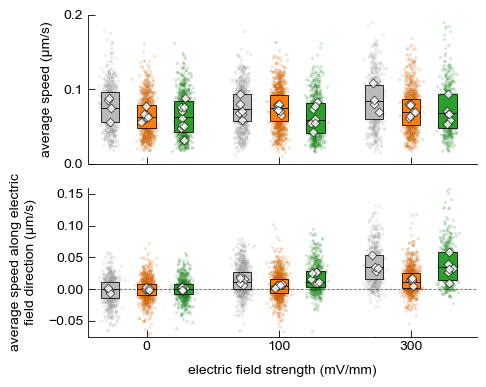

In [41]:
displacement_records_mag = []

# Assume z column exists in df_intervals_3
for (celltype, E), group in df_intervals_3[df_intervals_3.E_V_cm.isin([0, 1, 3])].groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        dy = np.diff(d['y'].values)
        dz = np.diff(d['z'].values)
        if len(dx) == 0:
            continue
        speeds = [sqrt(dx[i]**2 + dy[i]**2 + dz[i]**2) for i in range(len(dx))]
        mean_speed = np.mean(speeds)
        displacement_records_mag.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_speed': mean_speed / (3.0 * 60.0)  # Normalize for 3-frame interval (in μm/s)
        })

df_displacement_mag = pd.DataFrame(displacement_records_mag)

displacement_records = []

for (celltype, E), group in df_intervals_3.groupby(['celltype', 'E_V_cm']):
    for (date, trial, user, cell), d in group.groupby(['date', 'trial', 'user', 'cell']):
        if len(d) <= 3:
            continue
        d = d.sort_values('interval')
        dx = np.diff(d['x'].values)
        if len(dx) == 0:
            continue
        mean_dx = np.mean(dx)
        displacement_records.append({
            'celltype': celltype,
            'E_V_cm': E,
            'date': date,
            'trial': trial,
            'user': user,
            'cell': cell,
            'mean_dx': mean_dx
        })

df_displacement_proj = pd.DataFrame(displacement_records)

# Adjust to microns per second
df_displacement_proj['mean_speed'] = df_displacement_proj['mean_dx'] / (3.0 * 60.0)


######################
df_mag_plot = df_displacement_mag[df_displacement_mag.E_V_cm.isin([0, 1, 3])]
df_proj_plot = df_displacement_proj[df_displacement_proj.E_V_cm.isin([0, 1, 3])]


# Calculate average values per replicate for magnitude and projection
avg_mag_replicate = (
    df_mag_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

avg_proj_replicate = (
    df_proj_plot.groupby(['date', 'trial', 'user', 'E_V_cm', 'celltype'], as_index=False)
    ['mean_speed'].mean()
)

# Perform statistical tests (Mann-Whitney U) comparing averages of each replicate
from scipy.stats import mannwhitneyu

def run_stats(avg_df, E_levels, cell_a, cell_b):
    results = {}
    for E in E_levels:
        subset_a = avg_df[(avg_df.celltype == cell_a) & (avg_df.E_V_cm == E)]['mean_speed']
        subset_b = avg_df[(avg_df.celltype == cell_b) & (avg_df.E_V_cm == E)]['mean_speed']

        if len(subset_a) > 0 and len(subset_b) > 0:
            stat, p = mannwhitneyu(subset_a, subset_b, alternative='two-sided')
            results[E] = {'U_stat': stat, 'p_value': p, 'n_a': len(subset_a), 'n_b': len(subset_b)}
    return results

# Example cell types
cell_wt = 'dHL60KW'
cell_ko = 'dHL60TMEM154KO'
cell_rescue = 'dHL60TMEM154KO-clone1galvanin-GFP-HA'

print("\nMagnitude comparisons (KO vs WT):", run_stats(avg_mag_replicate, E_levels, cell_ko, cell_wt))
print("\nMagnitude comparisons (Rescue vs WT):", run_stats(avg_mag_replicate, E_levels, cell_rescue, cell_wt))

print("\nProjection comparisons (KO vs WT):", run_stats(avg_proj_replicate, E_levels, cell_ko, cell_wt))
print("\nProjection comparisons (Rescue vs WT):", run_stats(avg_proj_replicate, E_levels, cell_rescue, cell_wt))

# Settings
E_levels = [0, 1, 3]
celltypes = [wt, ko, res]
colors = [color_dict[wt], color_dict[ko], color_dict[res]]
celltype_color_dict = dict(zip(celltypes, colors))

group_spacing = 0.9
dodge_offset = 0.25
jitter_scale = 0.025
box_width = 0.125

# Setup 2-row figure
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 4), sharex=True)

titles = ["average speed (μm/s)", "average speed along electric\nfield direction (μm/s)"]
datasets = [df_mag_plot, df_proj_plot]
avg_datasets = [avg_mag_replicate, avg_proj_replicate]

for row, (ax, df_plot, avg_plot, ylabel) in enumerate(zip(axs, datasets, avg_datasets, titles)):
    legend_entries = {}
    
    for i, E in enumerate(E_levels):
        x_base = i * group_spacing
        for j, celltype in enumerate(celltypes):
            x_pos = x_base + (j - 1) * dodge_offset
            df_subset = df_plot[(df_plot.celltype == celltype) & (df_plot.E_V_cm == E)]
            speeds = df_subset['mean_speed'].values

            if len(speeds) == 0:
                continue

            # Boxplot
            ax.boxplot(
                [speeds],
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showcaps=True,
                showfliers=False,
                boxprops=dict(facecolor=celltype_color_dict[celltype], edgecolor='black', linewidth=.56),
                medianprops=dict(color='black', linewidth=0.6),
                whiskerprops=dict(color='black', linewidth=0),
                capprops=dict(color='black', linewidth=0),
            )

            # Jittered scatter (individual points)
            jittered_x = np.random.normal(loc=x_pos, scale=jitter_scale, size=len(speeds))
            scatter = ax.scatter(
                jittered_x, speeds,
                s=4, color=celltype_color_dict[celltype],
                alpha=0.2, edgecolor='black', linewidth=0.1,
                label=celltype if (E == 0 and celltype not in legend_entries) else None
            )
            legend_entries[celltype] = scatter

            # Scatter average replicate points
            avg_subset = avg_plot[(avg_plot.celltype == celltype) & (avg_plot.E_V_cm == E)]
            if not avg_subset.empty:
                avg_x = np.random.normal(loc=x_pos, scale=jitter_scale/2, size=len(avg_subset))
                ax.scatter(
                    avg_x, avg_subset['mean_speed'],
                    s=20, alpha=0.8,
                    marker='D', linewidth=0.5, edgecolor='black', color='white',#edgecolor='white', color='black',
                    zorder=5
                )

    # Formatting
    xticks = [i * group_spacing for i in range(len(E_levels))]
    xticklabels = [str(e * 100) for e in E_levels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10)
    ax.set_xlim(-0.4, 2.25)
    ax.set_ylabel(ylabel, fontsize=10)
    
    ax.grid(False)

    if ylabel == "average speed (μm/s)":
        yticks = [0,0.1, 0.2]
        ax.set_yticks(yticks)
        ax.set_ylim(0,0.2)
    else:
        ax.hlines(y=0, xmin=-1, xmax=3 + box_width, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
        yticks = [-0.05,0.0, 0.05, 0.1, 0.15]
        ax.set_yticks(yticks)
        ax.set_ylim(-0.075,0.16)

    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.6, length=5)
    ax.tick_params(axis='y', labelsize=10)

# Shared xlabel
axs[1].set_xlabel("electric field strength (mV/mm)", fontsize=10)

plt.tight_layout()
# fig.savefig('../../figures/Figure2_speeds_updated_2.pdf')

# Compass Autocorrelation

In [42]:
def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr

# generate autocorrelation list (compass autocorrelation for each trajectory
autocorr_list = []
for g, d in df_intervals_3.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'celltype': g[0],
        'E_V_cm': g[1],
        'lag': np.arange(len(acf)) * 3,  # actual lag in frames
        'autocorr': acf
    }))
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

# Calculate average for each time lag
df_avg_autocorr = df_autocorr.groupby(['celltype', 'E_V_cm', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()

     metric  E_V_cm                              celltype  n_test  n_control  \
0  autocorr       0                        dHL60TMEM154KO    1026        614   
1  autocorr       0  dHL60TMEM154KO-clone1galvanin-GFP-HA     769        614   
2  autocorr       1                        dHL60TMEM154KO    1131        779   
3  autocorr       1  dHL60TMEM154KO-clone1galvanin-GFP-HA     666        779   
4  autocorr       3                        dHL60TMEM154KO     976        538   
5  autocorr       3  dHL60TMEM154KO-clone1galvanin-GFP-HA     449        538   

   median_test  median_control       p_value  
0    -0.072368        0.028684  2.218611e-02  
1    -0.068033        0.028684  5.477356e-02  
2     0.018395        0.111306  2.789722e-03  
3     0.213513        0.111306  2.365543e-02  
4     0.115199        0.471758  1.586157e-17  
5     0.490543        0.471758  1.342543e-01  


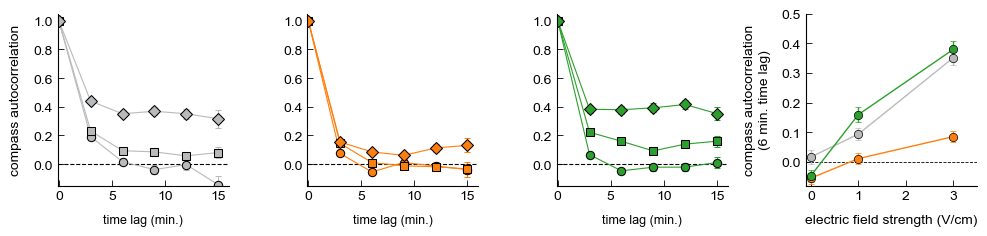

In [43]:
# Choose lag of interest (in minutes)
lag_of_interest = 6
df_lag = df_autocorr[df_autocorr.lag == lag_of_interest]

# Stats for bar plot
df_lag_stats = df_lag.groupby(['celltype', 'E_V_cm']).agg(
    mean_acf=('autocorr', 'mean'),
    sem_acf=('autocorr', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

# Unique celltypes
celltypes = df_avg_autocorr.celltype.unique()
n_celltypes = len(celltypes)

# Create figure with N+1 subplots in a row
fig, axes = plt.subplots(1, n_celltypes + 1, figsize=(2.5 * (n_celltypes + 1), 2.5))

# Time series autocorrelation plots (left side)
for ax, celltype in zip(axes[:-1], celltypes):
    data = df_avg_autocorr[df_avg_autocorr.celltype == celltype]
    for e, d in data.groupby('E_V_cm'):
        num_traj = d.num_trajectories.values[0]
        ax.errorbar(
            d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
            label=f"{e} V/cm (n={num_traj})",
            capsize=2,
            marker=marker_dict.get(e, 'o'),
            markersize=6,
            linewidth=0.8,
            color=color_dict.get(celltype, 'gray'),
            markeredgecolor='k',
            markeredgewidth=0.75
        )
    ax.set_xlim(-0.1, 5 * 3 + 1)
    ax.set_ylim(-0.15, 1.05)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('time lag (min.)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(False)

axes[0].set_ylabel('compass autocorrelation', fontsize=10)

# Plot for fixed lag (rightmost column)
for celltype, d in df_lag_stats.groupby('celltype'):
     axes[-1].errorbar(
        d['E_V_cm'], d['mean_acf'], yerr=d['sem_acf'],
        label=celltype,
        lw=1, marker='o', markersize=6,
        color=color_dict.get(celltype, None),
        zorder=10, capsize=2,
         markeredgecolor='k',
            markeredgewidth=0.5
    )

axes[-1].axhline(0, color='k', linestyle='--', zorder=0)
axes[-1].set_xlim(-0.1, 3.5)
axes[-1].set_ylim(-0.08, 0.5)
axes[-1].set_xlabel('electric field strength (V/cm)', fontsize=10)
axes[-1].set_ylabel('compass autocorrelation\n(6 min. time lag)', fontsize=10)
axes[-1].tick_params(labelsize=8)
axes[-1].grid(False)



for ax in axes:
    # Make all visible spines black
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)

    # Optionally hide top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Set tick color and width
    ax.tick_params(axis='both', colors='black', width=0.6, length=4, labelsize=10)
    
plt.tight_layout()

# plt.savefig('../../figures/Figure2_compassautocorr_updated_.pdf')

#################################
#################################
# Autocorrelation statistics (at one time lag)
#################################
#################################


# Define cell types
celltypes = df_avg_autocorr.celltype.unique()
# Explicitly define groups
test_celltypes = [
         'dHL60TMEM154KO',
       'dHL60TMEM154KO-clone1galvanin-GFP-HA'
]
control_celltype = 'dHL60KW'

def perform_mannwhitney_autocorr(df):
    df_lag6 = df[df['lag'] == 6]  # assuming lag 9 is desired
    results = []
    for ev in sorted(df_lag6['E_V_cm'].unique()):
        for test_ct in test_celltypes:
            group1 = df_lag6[(df_lag6['E_V_cm'] == ev) & (df_lag6['celltype'] == test_ct)]['autocorr'].dropna()
            group2 = df_lag6[(df_lag6['E_V_cm'] == ev) & (df_lag6['celltype'] == control_celltype)]['autocorr'].dropna()
            if len(group1) > 0 and len(group2) > 0:
                stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
                results.append({
                    'E_V_cm': ev,
                    'celltype': test_ct,
                    'control': control_celltype,
                    'statistic': stat,
                    'p_value': p,
                    'metric': 'autocorr',
                    'n_test': len(group1),
                    'n_control': len(group2),
                    'median_test': group1.median(),
                    'median_control': group2.median()
                })
    return pd.DataFrame(results)

df_stats_autocorr = perform_mannwhitney_autocorr(df_autocorr)

# Combine
df_stats_summary = df_stats_autocorr

# Optional: print or export
# print(df_stats_summary)
print(df_stats_summary[['metric', 'E_V_cm', 'celltype', 'n_test', 'n_control', 'median_test', 'median_control', 'p_value']])